# Demo ghi âm & `preprocess_audio`

Notebook minh họa pipeline tiền xử lý audio giống `app/common.py`:
1. Ghi âm (hoặc tải file WAV) và nghe lại
2. Chạy `preprocess_audio`
3. Nghe audio sau xử lý
4. So sánh waveform trước / sau

In [14]:
# Chạy một lần nếu thiếu thư viện
%pip install -q sounddevice matplotlib ipywidgets


Note: you may need to restart the kernel to use updated packages.


In [15]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import ipywidgets as widgets
from IPython.display import Audio, display, clear_output

# Thêm thư mục gốc ai_service để import app.common
NOTEBOOK_DIR = Path.cwd()
AI_ROOT = next(
    (p for p in (NOTEBOOK_DIR, NOTEBOOK_DIR.parent) if (p / "app" / "common.py").exists()),
    None,
)
if AI_ROOT is None:
    raise FileNotFoundError(
        "Không tìm thấy app/common.py — mở notebook từ thư mục ai_service hoặc train_model."
    )
sys.path.insert(0, str(AI_ROOT))

from app.common import preprocess_audio
from app.config import get_settings

settings = get_settings()
SAMPLE_RATE = settings.SAMPLE_RATE
print(f"Sample rate: {SAMPLE_RATE} Hz | MAX duration: {settings.MAX_AUDIO_DURATION_SEC}s")

Sample rate: 16000 Hz | MAX duration: 30.0s


## 1. Ghi âm & nghe lại

Dùng microphone máy tính:

1. Bấm **Bắt đầu ghi âm** → nói vào mic
2. Bấm **Dừng ghi âm** khi xong
3. Bấm **Nghe lại** để nghe bản ghi

> **Lưu ý:** Bản ghi giữ mức âm tự nhiên (không chuẩn hóa theo đỉnh) để tránh hiện tượng đầu file rất to, đoạn sau nhỏ do tiếng click lúc bật mic. Chuẩn hóa peak chỉ áp dụng ở bước `preprocess_audio` (mục 2).

Hoặc tải file `.wav` / `.mp3` bằng widget bên dưới.

In [ ]:
import librosa

audio_raw: np.ndarray | None = None

# Trạng thái ghi âm start/stop
_rec = {"active": False, "chunks": [], "stream": None}


def _audio_callback(indata, frames, time_info, status):
    if status:
        print(status)
    if _rec["active"]:
        _rec["chunks"].append(indata.copy())


def _start_recording():
    _rec["chunks"] = []
    _rec["active"] = True
    _rec["stream"] = sd.InputStream(
        samplerate=SAMPLE_RATE,
        channels=1,
        dtype="float32",
        callback=_audio_callback,
    )
    _rec["stream"].start()


def _stop_recording() -> np.ndarray | None:
    _rec["active"] = False
    if _rec["stream"] is not None:
        _rec["stream"].stop()
        _rec["stream"].close()
        _rec["stream"] = None
    if not _rec["chunks"]:
        return None
    audio = np.concatenate(_rec["chunks"], axis=0).flatten().astype(np.float32)
    # Không chia cho max(|audio|): spike đầu (click mic) làm phần sau nghe rất nhỏ.
    # Peak normalize chỉ dùng trong preprocess_audio (mục 2).
    return audio


def load_audio_file(path: str, sample_rate: int = SAMPLE_RATE) -> np.ndarray:
    y, _ = librosa.load(path, sr=sample_rate, mono=True)
    return y.astype(np.float32)


btn_record = widgets.Button(
    description="Bắt đầu ghi âm", button_style="danger", icon="microphone"
)
btn_play_raw = widgets.Button(
    description="Nghe lại", button_style="info", icon="play"
)
file_uploader = widgets.FileUpload(
    accept=".wav,.mp3,.ogg,.flac", multiple=False, description="Hoặc tải file"
)
output_record = widgets.Output()


def _on_toggle_record(_):
    global audio_raw
    with output_record:
        if not _rec["active"]:
            clear_output(wait=True)
            _start_recording()
            btn_record.description = "Dừng ghi âm"
            btn_record.button_style = "warning"
            btn_record.icon = "stop"
            print("Đang ghi âm... Nhấn «Dừng ghi âm» khi xong.")
        else:
            audio_raw = _stop_recording()
            btn_record.description = "Bắt đầu ghi âm"
            btn_record.button_style = "danger"
            btn_record.icon = "microphone"
            if audio_raw is None or len(audio_raw) == 0:
                print("Không thu được âm thanh — thử ghi lại.")
            else:
                dur = len(audio_raw) / SAMPLE_RATE
                print(f"Đã dừng. Số mẫu: {len(audio_raw):,} (~{dur:.2f}s)")
                print("Nhấn «Nghe lại» để nghe bản ghi.")


def _on_play_raw(_):
    with output_record:
        if audio_raw is None:
            print("Chưa có audio — hãy ghi âm hoặc tải file trước.")
            return
        if _rec["active"]:
            print("Đang ghi âm — hãy dừng trước khi nghe lại.")
            return
        clear_output(wait=True)
        display(Audio(audio_raw, rate=SAMPLE_RATE, normalize=False))


def _on_upload(change):
    global audio_raw
    if not change["new"]:
        return
    with output_record:
        clear_output(wait=True)
        uploaded = change["new"][0]
        tmp_path = Path("_uploaded_audio") / uploaded["name"]
        tmp_path.parent.mkdir(exist_ok=True)
        with open(tmp_path, "wb") as f:
            f.write(uploaded["content"])
        audio_raw = load_audio_file(str(tmp_path))
        max_len = int(settings.MAX_AUDIO_DURATION_SEC * SAMPLE_RATE)
        audio_raw = audio_raw[:max_len]
        print(f"Đã tải: {uploaded['name']} | {len(audio_raw):,} mẫu")
        print("Nhấn «Nghe lại» để nghe.")


btn_record.on_click(_on_toggle_record)
btn_play_raw.on_click(_on_play_raw)
file_uploader.observe(_on_upload, names="value")

display(widgets.VBox([
    widgets.HBox([btn_record, btn_play_raw]),
    file_uploader,
    output_record,
]))

## 2. `preprocess_audio` (giống `app/common.py`)

Các bước:
- Trim silence (`top_db=30`)
- Pre-emphasis (hệ số 0.97)
- Peak normalize về ±1.0


In [17]:
if audio_raw is None:
    raise RuntimeError("Chưa có audio_raw — quay lại mục 1 để ghi âm hoặc tải file.")

audio_processed = preprocess_audio(audio_raw.copy())

print(f"Trước:  {len(audio_raw):,} mẫu ({len(audio_raw) / SAMPLE_RATE:.2f}s)")
print(f"Sau:    {len(audio_processed):,} mẫu ({len(audio_processed) / SAMPLE_RATE:.2f}s)")
print(f"Peak trước: {np.max(np.abs(audio_raw)):.4f} | Peak sau: {np.max(np.abs(audio_processed)):.4f}")

Trước:  23,040 mẫu (1.44s)
Sau:    22,528 mẫu (1.41s)
Peak trước: 0.7847 | Peak sau: 1.0000


## 3. Nghe lại âm thanh sau preprocess

In [18]:
print("--- Trước preprocess ---")
display(Audio(audio_raw, rate=SAMPLE_RATE, normalize=False))

print("--- Sau preprocess ---")
display(Audio(audio_processed, rate=SAMPLE_RATE, normalize=False))

--- Trước preprocess ---


--- Sau preprocess ---


## 4. Biểu đồ waveform trước & sau

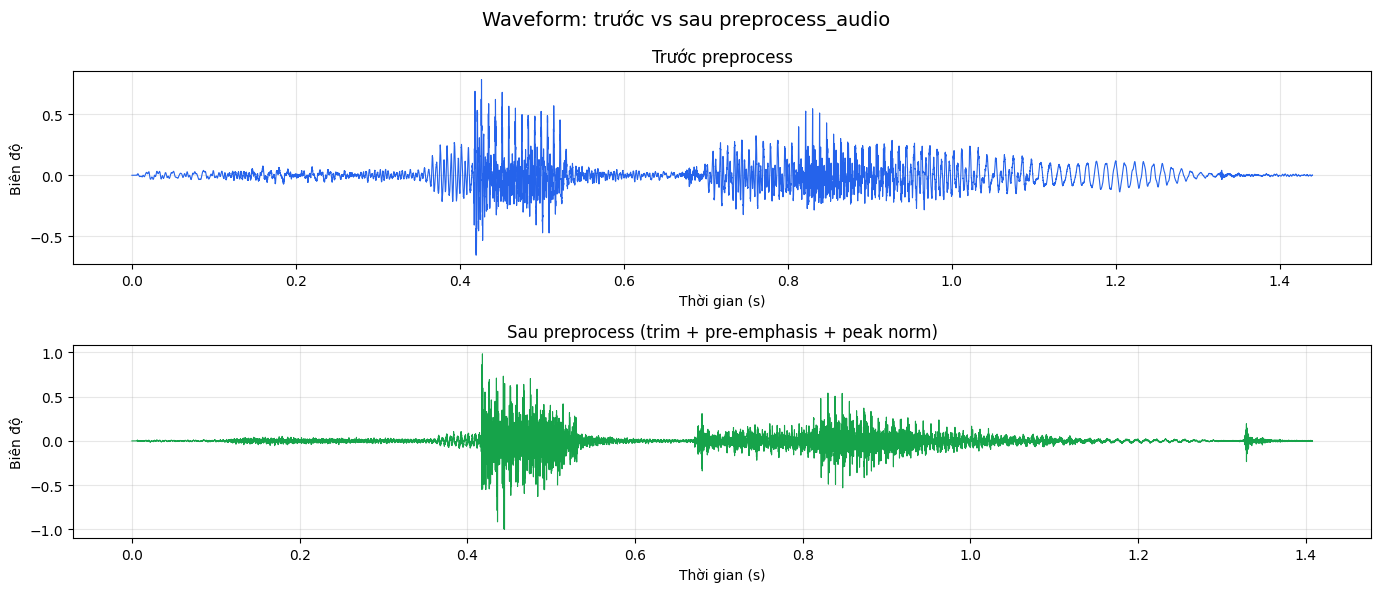

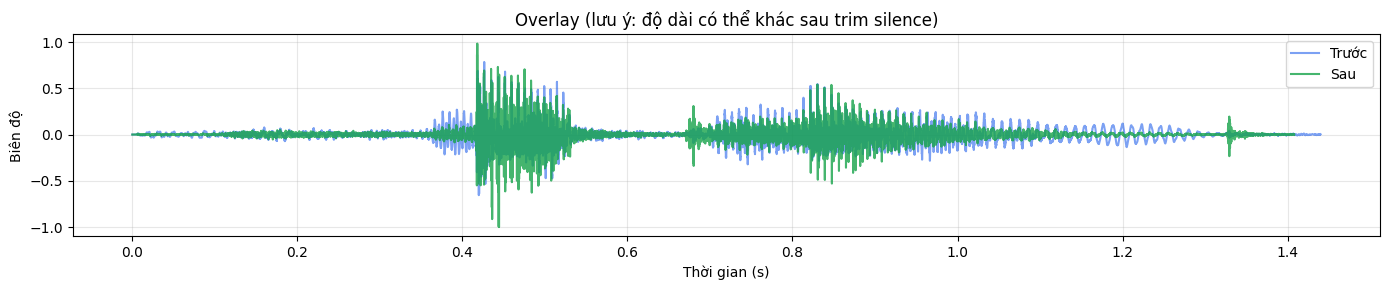

In [19]:
def time_axis(n_samples: int, sr: int) -> np.ndarray:
    return np.arange(n_samples) / sr


fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
fig.suptitle("Waveform: trước vs sau preprocess_audio", fontsize=14)

t_raw = time_axis(len(audio_raw), SAMPLE_RATE)
t_proc = time_axis(len(audio_processed), SAMPLE_RATE)

axes[0].plot(t_raw, audio_raw, color="#2563eb", linewidth=0.8)
axes[0].set_title("Trước preprocess")
axes[0].set_ylabel("Biên độ")
axes[0].set_xlabel("Thời gian (s)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_proc, audio_processed, color="#16a34a", linewidth=0.8)
axes[1].set_title("Sau preprocess (trim + pre-emphasis + peak norm)")
axes[1].set_ylabel("Biên độ")
axes[1].set_xlabel("Thời gian (s)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overlay ngắn gọn (cùng trục thời gian từ 0)
fig2, ax = plt.subplots(figsize=(14, 3))
ax.plot(t_raw, audio_raw, alpha=0.6, label="Trước", color="#2563eb")
ax.plot(t_proc, audio_processed, alpha=0.8, label="Sau", color="#16a34a")
ax.set_title("Overlay (lưu ý: độ dài có thể khác sau trim silence)")
ax.set_xlabel("Thời gian (s)")
ax.set_ylabel("Biên độ")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()